# Assignment 1: Data Preprocessing and Feature Selection

## Tajuk
**Public Transport Ridership Demand Prediction in Kuala Lumpur**

## Ringkasan
Kajian ini menggunakan data ridership pengangkutan awam sebagai data utama. Data ini digabungkan dengan data harga minyak, data cuti umum Malaysia dan data cuaca Kuala Lumpur.

Tujuan utama adalah untuk meramal sama ada sesuatu hari mempunyai permintaan pengangkutan awam yang tinggi atau tidak.

Target yang digunakan:

`high_demand`

Nilai target:

- `1` = permintaan tinggi
- `0` = permintaan biasa atau rendah

## Sumber Data

Dataset yang digunakan:

1. **Ridership public transport**
   - File: `https://data.gov.my/data-catalogue/ridership_headline?visual=table`

2. **Fuel price**
   - File: `https://data.gov.my/data-catalogue/fuelprice?series_type=level&visual=table`

3. **Public holiday Malaysia**
   - Dijana menggunakan library `holidays`

4. **Weather Kuala Lumpur**
   - Diambil menggunakan Open-Meteo API

Data digabungkan menggunakan column `date`.

In [85]:
# Install library yang diperlukan
!pip install pandas numpy matplotlib scikit-learn requests holidays

In [86]:
# Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import holidays

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif, RFE
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

pd.set_option("display.max_columns", None)

# 1. Load Dataset

Dua dataset utama dibaca daripada folder Downloads. Path file diletakkan terus supaya mudah dijalankan semula.

In [87]:
# Path dataset
ridership_path = "/Users/rajayusof/Downloads/ridership_headline.csv"
fuel_path = "/Users/rajayusof/Downloads/fuelprice.csv"

# Baca dataset
ridership = pd.read_csv(ridership_path)
fuel = pd.read_csv(fuel_path)

print("Shape ridership:", ridership.shape)
display(ridership.head())

print("Shape fuel price:", fuel.shape)
display(fuel.head())

Shape ridership: (2647, 14)


,date,bus_rkl,bus_rkn,bus_rpn,rail_lrt_ampang,rail_mrt_kajang,rail_lrt_kj,rail_monorail,rail_mrt_pjy,rail_ets,rail_intercity,rail_komuter_utara,rail_tebrau,rail_komuter
0,2019-01-01,NaN,NaN,NaN,113357,114173,139634,35804,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-02,NaN,NaN,NaN,182715,169316,274224,31859,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-03,NaN,NaN,NaN,187904,175304,286469,31893,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-04,NaN,NaN,NaN,198420,187891,304755,34121,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-05,NaN,NaN,NaN,120773,112660,145036,29950,NaN,NaN,NaN,NaN,NaN,NaN


Shape fuel price: (915, 8)


,series_type,date,ron95,ron97,diesel,diesel_eastmsia,ron95_budi95,ron95_skps
0,level,2017-03-30,2.13,2.41,2.11,2.11,NaN,NaN
1,level,2017-04-06,2.16,2.43,2.08,2.08,NaN,NaN
2,level,2017-04-13,2.24,2.52,2.16,2.16,NaN,NaN
3,level,2017-04-20,2.27,2.54,2.21,2.21,NaN,NaN
4,level,2017-04-27,2.21,2.49,2.14,2.14,NaN,NaN


In [88]:
# Semak nama column dan missing value
print("Column ridership:")
print(ridership.columns.tolist())

print("\nColumn fuel price:")
print(fuel.columns.tolist())

print("\nMissing value ridership:")
display(ridership.isna().sum())

print("\nMissing value fuel price:")
display(fuel.isna().sum())

Column ridership:
['date', 'bus_rkl', 'bus_rkn', 'bus_rpn', 'rail_lrt_ampang', 'rail_mrt_kajang', 'rail_lrt_kj', 'rail_monorail', 'rail_mrt_pjy', 'rail_ets', 'rail_intercity', 'rail_komuter_utara', 'rail_tebrau', 'rail_komuter']

Column fuel price:
['series_type', 'date', 'ron95', 'ron97', 'diesel', 'diesel_eastmsia', 'ron95_budi95', 'ron95_skps']

Missing value ridership:


date                     0
bus_rkl               1096
bus_rkn               1096
bus_rpn               1096
rail_lrt_ampang          0
rail_mrt_kajang          0
rail_lrt_kj              0
rail_monorail            0
rail_mrt_pjy          1262
rail_ets               653
rail_intercity         653
rail_komuter_utara     653
rail_tebrau           1265
rail_komuter          1713
dtype: int64


Missing value fuel price:


series_type          0
date                 0
ron95                0
ron97                0
diesel               0
diesel_eastmsia      0
ron95_budi95       856
ron95_skps         856
dtype: int64

# 2. Penyediaan Data Ridership

Data ridership digunakan untuk membina target `high_demand`.

Langkah yang dibuat:

1. Tukar `date` kepada format datetime.
2. Isi missing value ridership dengan `0`.
3. Jumlahkan semua ridership harian.
4. Bina label `high_demand` berdasarkan nilai median.

In [89]:
# Tukar date kepada datetime
ridership["date"] = pd.to_datetime(ridership["date"])

# Ambil semua column ridership kecuali date
ridership_columns = ridership.columns.drop("date")

# Isi missing value dengan 0
ridership[ridership_columns] = ridership[ridership_columns].fillna(0)

# Jumlah ridership setiap hari
ridership["total_ridership"] = ridership[ridership_columns].sum(axis=1)

# Buat target guna median
median_ridership = ridership["total_ridership"].median()

ridership["high_demand"] = np.where(
    ridership["total_ridership"] > median_ridership,
    1,
    0
)

# Simpan column penting sahaja
ridership_label = ridership[["date", "total_ridership", "high_demand"]].copy()

display(ridership_label.head())
print("Median total ridership:", median_ridership)
print("\nTaburan target:")
print(ridership_label["high_demand"].value_counts())

,date,total_ridership,high_demand
0,2019-01-01,402968.0,0
1,2019-01-02,658114.0,0
2,2019-01-03,681570.0,0
3,2019-01-04,725187.0,0
4,2019-01-05,408419.0,0


Median total ridership: 768796.0

Taburan target:
high_demand
0    1324
1    1323
Name: count, dtype: int64


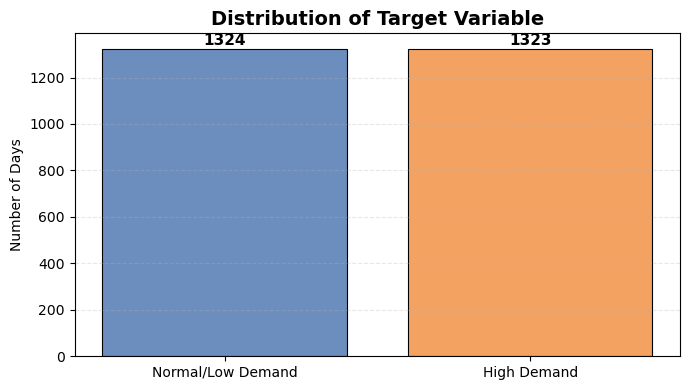

In [90]:
# Visual ringkas target
target_count = ridership_label["high_demand"].value_counts().sort_index()
target_label = ["Normal/Low Demand", "High Demand"]
target_colors = ["#6C8EBF", "#F4A261"]

plt.figure(figsize=(7, 4))
bars = plt.bar(target_label, target_count.values, color=target_colors, edgecolor="black", linewidth=0.8)

plt.title("Distribution of Target Variable", fontsize=14, fontweight="bold")
plt.ylabel("Number of Days")
plt.grid(axis="y", linestyle="--", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(height)}",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

# 3. Penyediaan Data Fuel Price

Data harga minyak asal berbentuk mingguan. Disebabkan data ridership adalah harian, harga minyak ditukar kepada bentuk harian menggunakan forward fill.

Forward fill digunakan kerana harga minyak biasanya kekal sehingga harga baru diumumkan.

In [91]:
# Tukar date fuel kepada datetime
fuel["date"] = pd.to_datetime(fuel["date"])

# Guna data harga sebenar sahaja
fuel_level = fuel[fuel["series_type"] == "level"].copy()

# Pilih column harga minyak yang diperlukan
fuel_level = fuel_level[[
    "date",
    "ron95",
    "ron97",
    "diesel",
    "diesel_eastmsia"
]]

# Buat date range harian ikut data ridership
date_range = pd.DataFrame({
    "date": pd.date_range(
        start=ridership_label["date"].min(),
        end=ridership_label["date"].max(),
        freq="D"
    )
})

# Merge harga minyak mingguan kepada harian
fuel_daily = date_range.merge(fuel_level, on="date", how="left")

# Isi nilai kosong
fuel_cols = ["ron95", "ron97", "diesel", "diesel_eastmsia"]
fuel_daily[fuel_cols] = fuel_daily[fuel_cols].ffill().bfill()

display(fuel_daily.head())
print("Missing value fuel_daily:")
display(fuel_daily.isna().sum())

,date,ron95,ron97,diesel,diesel_eastmsia
0,2019-01-01,2.20,2.50,2.18,2.18
1,2019-01-02,2.20,2.50,2.18,2.18
2,2019-01-03,2.20,2.50,2.18,2.18
3,2019-01-04,2.20,2.50,2.18,2.18
4,2019-01-05,1.93,2.23,2.04,2.04


Missing value fuel_daily:


date               0
ron95              0
ron97              0
diesel             0
diesel_eastmsia    0
dtype: int64

# 4. Data Cuti Umum Malaysia

Data cuti umum dijana menggunakan library `holidays`.

Feature yang digunakan:

- `is_public_holiday`
- `holiday_name`

Untuk model, `is_public_holiday` digunakan sebagai feature.

In [92]:
# Tahun mula dan tahun akhir
start_year = ridership_label["date"].dt.year.min()
end_year = ridership_label["date"].dt.year.max()

# Senarai cuti Malaysia
malaysia_holidays = holidays.country_holidays(
    "MY",
    years=range(start_year, end_year + 1)
)

holiday_df = date_range.copy()

# Nama cuti
holiday_df["holiday_name"] = holiday_df["date"].dt.date.map(
    lambda x: malaysia_holidays.get(x)
)

# 1 kalau cuti umum, 0 kalau bukan
holiday_df["is_public_holiday"] = holiday_df["holiday_name"].notna().astype(int)
holiday_df["holiday_name"] = holiday_df["holiday_name"].fillna("No Holiday")

display(holiday_df.head())
print("Bilangan cuti dan bukan cuti:")
print(holiday_df["is_public_holiday"].value_counts())

,date,holiday_name,is_public_holiday
0,2019-01-01,No Holiday,0
1,2019-01-02,No Holiday,0
2,2019-01-03,No Holiday,0
3,2019-01-04,No Holiday,0
4,2019-01-05,No Holiday,0


Bilangan cuti dan bukan cuti:
is_public_holiday
0    2534
1     113
Name: count, dtype: int64


# 5. Data Cuaca Kuala Lumpur

Data cuaca diambil daripada Open-Meteo API menggunakan lokasi Kuala Lumpur.

Lokasi:

- Latitude: `3.1390`
- Longitude: `101.6869`

Feature cuaca yang digunakan termasuk suhu, hujan, jumlah jam hujan dan kelajuan angin.

In [93]:
# Tarikh mula dan akhir untuk API
start_date = ridership_label["date"].min().strftime("%Y-%m-%d")
end_date = ridership_label["date"].max().strftime("%Y-%m-%d")

# Lokasi Kuala Lumpur
latitude = 3.1390
longitude = 101.6869

url = "https://archive-api.open-meteo.com/v1/archive"

params = {
    "latitude": latitude,
    "longitude": longitude,
    "start_date": start_date,
    "end_date": end_date,
    "daily": [
        "temperature_2m_mean",
        "temperature_2m_max",
        "temperature_2m_min",
        "precipitation_sum",
        "rain_sum",
        "precipitation_hours",
        "wind_speed_10m_max"
    ],
    "timezone": "Asia/Kuala_Lumpur"
}

response = requests.get(url, params=params)
response.raise_for_status()

weather_json = response.json()

weather = pd.DataFrame(weather_json["daily"])
weather = weather.rename(columns={"time": "date"})
weather["date"] = pd.to_datetime(weather["date"])

display(weather.head())
print("Shape weather:", weather.shape)
print("Missing value weather:")
display(weather.isna().sum())

,date,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max
0,2019-01-01,26.7,30.4,23.5,6.8,6.8,8.0,10.1
1,2019-01-02,26.6,30.3,23.2,1.3,1.3,6.0,13.5
2,2019-01-03,26.3,29.6,23.3,1.1,1.1,8.0,26.4
3,2019-01-04,26.6,30.2,23.9,0.6,0.6,5.0,19.1
4,2019-01-05,27.1,31.7,21.5,1.6,1.6,4.0,7.7


Shape weather: (2647, 8)
Missing value weather:


date                   0
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
precipitation_sum      0
rain_sum               0
precipitation_hours    0
wind_speed_10m_max     0
dtype: int64

# 6. Gabung Semua Dataset

Semua dataset digabungkan menggunakan column `date`.

Dataset akhir mengandungi:

- Label demand
- Harga minyak
- Cuti umum
- Cuaca Kuala Lumpur

In [94]:
# Merge semua data ikut date
model_df = ridership_label.merge(fuel_daily, on="date", how="left")
model_df = model_df.merge(holiday_df, on="date", how="left")
model_df = model_df.merge(weather, on="date", how="left")

display(model_df.head())
print("Shape selepas merge:", model_df.shape)

print("\nMissing value selepas merge:")
display(model_df.isna().sum())

,date,total_ridership,high_demand,ron95,ron97,diesel,diesel_eastmsia,holiday_name,is_public_holiday,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max
0,2019-01-01,402968.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.7,30.4,23.5,6.8,6.8,8.0,10.1
1,2019-01-02,658114.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.6,30.3,23.2,1.3,1.3,6.0,13.5
2,2019-01-03,681570.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.3,29.6,23.3,1.1,1.1,8.0,26.4
3,2019-01-04,725187.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.6,30.2,23.9,0.6,0.6,5.0,19.1
4,2019-01-05,408419.0,0,1.93,2.23,2.04,2.04,No Holiday,0,27.1,31.7,21.5,1.6,1.6,4.0,7.7


Shape selepas merge: (2647, 16)

Missing value selepas merge:


date                   0
total_ridership        0
high_demand            0
ron95                  0
ron97                  0
diesel                 0
diesel_eastmsia        0
holiday_name           0
is_public_holiday      0
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
precipitation_sum      0
rain_sum               0
precipitation_hours    0
wind_speed_10m_max     0
dtype: int64

# 7. Data Preprocessing

Missing value dikendalikan menggunakan kaedah yang ringkas:

- Numeric data: forward fill dan backward fill
- Categorical data: isi dengan `"No Holiday"`

Data juga disusun mengikut tarikh sebelum proses fill dibuat.

In [95]:
# Susun ikut tarikh
model_df = model_df.sort_values("date").reset_index(drop=True)

print("Missing value sebelum handling:")
display(model_df.isna().sum())

# Isi missing value numeric
numeric_cols = model_df.select_dtypes(include=["int64", "float64"]).columns
model_df[numeric_cols] = model_df[numeric_cols].ffill().bfill()

# Isi missing value categorical
model_df["holiday_name"] = model_df["holiday_name"].fillna("No Holiday")

print("Missing value selepas handling:")
display(model_df.isna().sum())

Missing value sebelum handling:


date                   0
total_ridership        0
high_demand            0
ron95                  0
ron97                  0
diesel                 0
diesel_eastmsia        0
holiday_name           0
is_public_holiday      0
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
precipitation_sum      0
rain_sum               0
precipitation_hours    0
wind_speed_10m_max     0
dtype: int64

Missing value selepas handling:


date                   0
total_ridership        0
high_demand            0
ron95                  0
ron97                  0
diesel                 0
diesel_eastmsia        0
holiday_name           0
is_public_holiday      0
temperature_2m_mean    0
temperature_2m_max     0
temperature_2m_min     0
precipitation_sum      0
rain_sum               0
precipitation_hours    0
wind_speed_10m_max     0
dtype: int64

# 8. Feature Engineering

Beberapa feature baru dibina daripada tarikh:

- `day_of_week`
- `day_name`
- `month`
- `year`
- `is_weekend`

Feature ini digunakan sebab corak ridership boleh berubah mengikut hari bekerja, hujung minggu dan bulan tertentu.

In [96]:
# Feature daripada tarikh
model_df["day_of_week"] = model_df["date"].dt.dayofweek
model_df["day_name"] = model_df["date"].dt.day_name()
model_df["month"] = model_df["date"].dt.month
model_df["year"] = model_df["date"].dt.year
model_df["is_weekend"] = model_df["day_of_week"].isin([5, 6]).astype(int)

display(model_df.head())

,date,total_ridership,high_demand,ron95,ron97,diesel,diesel_eastmsia,holiday_name,is_public_holiday,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,day_of_week,day_name,month,year,is_weekend
0,2019-01-01,402968.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.7,30.4,23.5,6.8,6.8,8.0,10.1,1,Tuesday,1,2019,0
1,2019-01-02,658114.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.6,30.3,23.2,1.3,1.3,6.0,13.5,2,Wednesday,1,2019,0
2,2019-01-03,681570.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.3,29.6,23.3,1.1,1.1,8.0,26.4,3,Thursday,1,2019,0
3,2019-01-04,725187.0,0,2.20,2.50,2.18,2.18,No Holiday,0,26.6,30.2,23.9,0.6,0.6,5.0,19.1,4,Friday,1,2019,0
4,2019-01-05,408419.0,0,1.93,2.23,2.04,2.04,No Holiday,0,27.1,31.7,21.5,1.6,1.6,4.0,7.7,5,Saturday,1,2019,1


# 9. Feature dan Target

Target:

`high_demand`

Feature yang digunakan terdiri daripada harga minyak, cuti umum, cuaca dan ciri tarikh.

`total_ridership` tidak digunakan sebagai feature kerana column itu digunakan untuk membina target. Jika digunakan, result model akan jadi tidak adil.

In [97]:
# Senarai feature untuk model
features = [
    "ron95",
    "ron97",
    "diesel",
    "diesel_eastmsia",
    "is_public_holiday",
    "day_of_week",
    "day_name",
    "month",
    "year",
    "is_weekend",
    "temperature_2m_mean",
    "temperature_2m_max",
    "temperature_2m_min",
    "precipitation_sum",
    "rain_sum",
    "precipitation_hours",
    "wind_speed_10m_max"
]

X = model_df[features].copy()
y = model_df["high_demand"].copy()

display(X.head())
print("Shape X:", X.shape)
print("Shape y:", y.shape)

,ron95,ron97,diesel,diesel_eastmsia,is_public_holiday,day_of_week,day_name,month,year,is_weekend,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max
0,2.20,2.50,2.18,2.18,0,1,Tuesday,1,2019,0,26.7,30.4,23.5,6.8,6.8,8.0,10.1
1,2.20,2.50,2.18,2.18,0,2,Wednesday,1,2019,0,26.6,30.3,23.2,1.3,1.3,6.0,13.5
2,2.20,2.50,2.18,2.18,0,3,Thursday,1,2019,0,26.3,29.6,23.3,1.1,1.1,8.0,26.4
3,2.20,2.50,2.18,2.18,0,4,Friday,1,2019,0,26.6,30.2,23.9,0.6,0.6,5.0,19.1
4,1.93,2.23,2.04,2.04,0,5,Saturday,1,2019,1,27.1,31.7,21.5,1.6,1.6,4.0,7.7


Shape X: (2647, 17)
Shape y: (2647,)


# 10. Encoding

Column `day_name` ialah data kategori. Jadi column ini ditukar kepada bentuk nombor menggunakan one-hot encoding.

In [98]:
# One-hot encoding untuk day_name
X_encoded = pd.get_dummies(
    X,
    columns=["day_name"],
    drop_first=False
)

# Tukar boolean kepada 0 dan 1
bool_cols = X_encoded.select_dtypes(include=["bool"]).columns
for col in bool_cols:
    X_encoded[col] = X_encoded[col].astype(int)

print("Shape sebelum encoding:", X.shape)
print("Shape selepas encoding:", X_encoded.shape)
display(X_encoded.head())

Shape sebelum encoding: (2647, 17)
Shape selepas encoding: (2647, 23)


,ron95,ron97,diesel,diesel_eastmsia,is_public_holiday,day_of_week,month,year,is_weekend,temperature_2m_mean,temperature_2m_max,temperature_2m_min,precipitation_sum,rain_sum,precipitation_hours,wind_speed_10m_max,day_name_Friday,day_name_Monday,day_name_Saturday,day_name_Sunday,day_name_Thursday,day_name_Tuesday,day_name_Wednesday
0,2.20,2.50,2.18,2.18,0,1,1,2019,0,26.7,30.4,23.5,6.8,6.8,8.0,10.1,0,0,0,0,0,1,0
1,2.20,2.50,2.18,2.18,0,2,1,2019,0,26.6,30.3,23.2,1.3,1.3,6.0,13.5,0,0,0,0,0,0,1
2,2.20,2.50,2.18,2.18,0,3,1,2019,0,26.3,29.6,23.3,1.1,1.1,8.0,26.4,0,0,0,0,1,0,0
3,2.20,2.50,2.18,2.18,0,4,1,2019,0,26.6,30.2,23.9,0.6,0.6,5.0,19.1,1,0,0,0,0,0,0
4,1.93,2.23,2.04,2.04,0,5,1,2019,1,27.1,31.7,21.5,1.6,1.6,4.0,7.7,0,0,1,0,0,0,0


# 11. Train-Test Split dan Standardization

Data dibahagikan kepada:

- 80% training
- 20% testing

Standardization dibuat supaya semua numeric feature berada pada skala yang lebih seimbang.

In [99]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardization
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tukar balik kepada dataframe
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_encoded.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_encoded.columns,
    index=X_test.index
)

print("Train shape:", X_train_scaled.shape)
print("Test shape:", X_test_scaled.shape)

Train shape: (2117, 23)
Test shape: (530, 23)


# 12. Function Evaluation

Model yang digunakan ialah Logistic Regression kerana target mempunyai dua kelas sahaja.

Metric yang digunakan:

- Accuracy
- Precision
- Recall
- F1 Score

In [100]:
# Function untuk train dan evaluate model
def evaluate_model(model_name, X_train_data, X_test_data, y_train_data, y_test_data):
    model = LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        random_state=42
    )

    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)

    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred, zero_division=0)
    recall = recall_score(y_test_data, y_pred, zero_division=0)
    f1 = f1_score(y_test_data, y_pred, zero_division=0)

    print("=" * 55)
    print(model_name)
    print("=" * 55)
    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test_data, y_pred, zero_division=0))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

# 13. Baseline Model

Model pertama menggunakan semua feature. Result ini digunakan sebagai perbandingan sebelum feature selection dibuat.

In [101]:
results = []

baseline_result = evaluate_model(
    "Baseline: All Features",
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test
)

results.append(baseline_result)

Baseline: All Features
Accuracy : 0.8679
Precision: 0.8652
Recall   : 0.8717
F1 Score : 0.8684

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.87       265
           1       0.87      0.87      0.87       265

    accuracy                           0.87       530
   macro avg       0.87      0.87      0.87       530
weighted avg       0.87      0.87      0.87       530



# 14. Feature Selection 1: Mutual Information

Mutual Information digunakan untuk melihat hubungan setiap feature dengan target `high_demand`.

Feature yang mempunyai score lebih tinggi dianggap lebih membantu model.

In [102]:
# Pilih bilangan feature terbaik
k = 8

mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k=k
)

mi_selector.fit(X_train_scaled, y_train)

mi_scores = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "MI Score": mi_selector.scores_
}).sort_values(by="MI Score", ascending=False)

display(mi_scores)

selected_features_mi = mi_scores.head(k)["Feature"].tolist()

print("Feature dipilih oleh Mutual Information:")
for feature in selected_features_mi:
    print("-", feature)

,Feature,MI Score
1,ron97,0.385301
7,year,0.363591
2,diesel,0.263121
0,ron95,0.164653
3,diesel_eastmsia,0.135051
5,day_of_week,0.037012
18,day_name_Saturday,0.029156
10,temperature_2m_max,0.019129
4,is_public_holiday,0.016653
8,is_weekend,0.016119


Feature dipilih oleh Mutual Information:
- ron97
- year
- diesel
- ron95
- diesel_eastmsia
- day_of_week
- day_name_Saturday
- temperature_2m_max


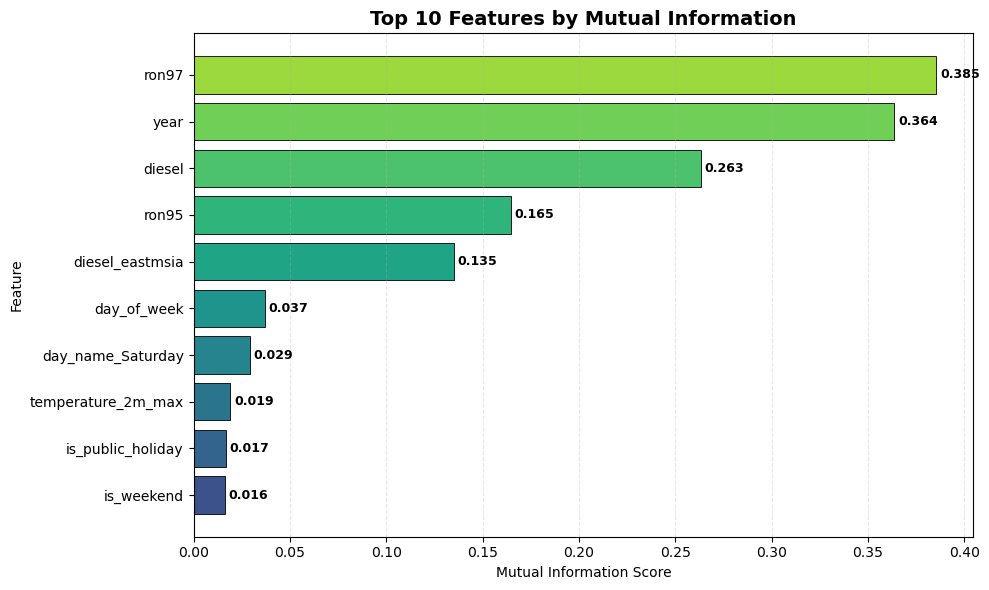

In [103]:
# Graph Mutual Information
top_mi = mi_scores.head(10).sort_values("MI Score")

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(top_mi)))

bars = plt.barh(
    top_mi["Feature"],
    top_mi["MI Score"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.title("Top 10 Features by Mutual Information", fontsize=14, fontweight="bold")
plt.xlabel("Mutual Information Score")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [104]:
# Evaluate model selepas Mutual Information
mi_result = evaluate_model(
    "After Mutual Information",
    X_train_scaled[selected_features_mi],
    X_test_scaled[selected_features_mi],
    y_train,
    y_test
)

results.append(mi_result)

After Mutual Information
Accuracy : 0.8811
Precision: 0.8826
Recall   : 0.8792
F1 Score : 0.8809

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       265
           1       0.88      0.88      0.88       265

    accuracy                           0.88       530
   macro avg       0.88      0.88      0.88       530
weighted avg       0.88      0.88      0.88       530



# 15. Feature Selection 2: Recursive Feature Elimination

Recursive Feature Elimination memilih feature dengan cara membuang feature yang kurang penting secara berperingkat.

Dalam bahagian ini, 8 feature terbaik dipilih.

In [105]:
# Model untuk RFE
rfe_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

# RFE
rfe_selector = RFE(
    estimator=rfe_model,
    n_features_to_select=8
)

rfe_selector.fit(X_train_scaled, y_train)

rfe_result_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Selected": rfe_selector.support_,
    "Ranking": rfe_selector.ranking_
}).sort_values(by="Ranking")

display(rfe_result_df)

selected_features_rfe = rfe_result_df[rfe_result_df["Selected"] == True]["Feature"].tolist()

print("Feature dipilih oleh RFE:")
for feature in selected_features_rfe:
    print("-", feature)

,Feature,Selected,Ranking
0,ron95,True,1
2,diesel,True,1
3,diesel_eastmsia,True,1
5,day_of_week,True,1
6,month,True,1
7,year,True,1
8,is_weekend,True,1
19,day_name_Sunday,True,1
4,is_public_holiday,False,2
10,temperature_2m_max,False,3


Feature dipilih oleh RFE:
- ron95
- diesel
- diesel_eastmsia
- day_of_week
- month
- year
- is_weekend
- day_name_Sunday


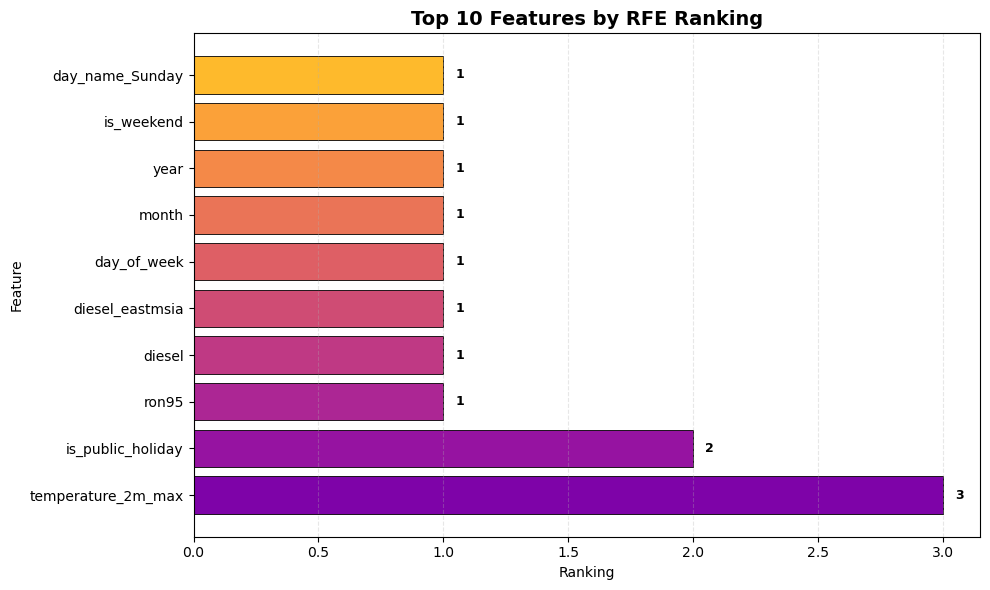

In [106]:
# Graph RFE
top_rfe = rfe_result_df.head(10).sort_values("Ranking", ascending=False)

plt.figure(figsize=(10, 6))
colors = plt.cm.plasma(np.linspace(0.25, 0.85, len(top_rfe)))

bars = plt.barh(
    top_rfe["Feature"],
    top_rfe["Ranking"],
    color=colors,
    edgecolor="black",
    linewidth=0.6
)

plt.title("Top 10 Features by RFE Ranking", fontsize=14, fontweight="bold")
plt.xlabel("Ranking")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.3)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width)}",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

In [107]:
# Evaluate model selepas RFE
rfe_result = evaluate_model(
    "After RFE",
    X_train_scaled[selected_features_rfe],
    X_test_scaled[selected_features_rfe],
    y_train,
    y_test
)

results.append(rfe_result)

After RFE
Accuracy : 0.8774
Precision: 0.8817
Recall   : 0.8717
F1 Score : 0.8767

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.88      0.88       265
           1       0.88      0.87      0.88       265

    accuracy                           0.88       530
   macro avg       0.88      0.88      0.88       530
weighted avg       0.88      0.88      0.88       530



# 16. Dimensionality Reduction: PCA

PCA digunakan untuk mengurangkan bilangan feature sambil mengekalkan kebanyakan maklumat asal.

Dalam kajian ini, PCA ditetapkan untuk mengekalkan 95% variance.

In [108]:
# PCA
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Bilangan feature asal:", X_train_scaled.shape[1])
print("Bilangan komponen PCA:", X_train_pca.shape[1])
print("Total explained variance:", round(pca.explained_variance_ratio_.sum(), 4))

Bilangan feature asal: 23
Bilangan komponen PCA: 15
Total explained variance: 0.9693


In [109]:
# Evaluate model selepas PCA
pca_result = evaluate_model(
    "After PCA",
    X_train_pca,
    X_test_pca,
    y_train,
    y_test
)

results.append(pca_result)

After PCA
Accuracy : 0.8528
Precision: 0.8476
Recall   : 0.8604
F1 Score : 0.8539

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       265
           1       0.85      0.86      0.85       265

    accuracy                           0.85       530
   macro avg       0.85      0.85      0.85       530
weighted avg       0.85      0.85      0.85       530



# 17. Perbandingan Prestasi Model

Result semua model dibandingkan untuk melihat kesan feature selection terhadap prestasi model.

Model yang dibandingkan:

1. Baseline
2. Mutual Information
3. RFE
4. PCA

In [110]:
# Jadual result
results_df = pd.DataFrame(results)

# Round decimal supaya jadual nampak kemas
results_display = results_df.copy()

metric_columns = ["Accuracy", "Precision", "Recall", "F1 Score"]

for col in metric_columns:
    results_display[col] = results_display[col].round(4)

display(results_display)

,Model,Accuracy,Precision,Recall,F1 Score
0,Baseline: All Features,0.8679,0.8652,0.8717,0.8684
1,After Mutual Information,0.8811,0.8826,0.8792,0.8809
2,After RFE,0.8774,0.8817,0.8717,0.8767
3,After PCA,0.8528,0.8476,0.8604,0.8539


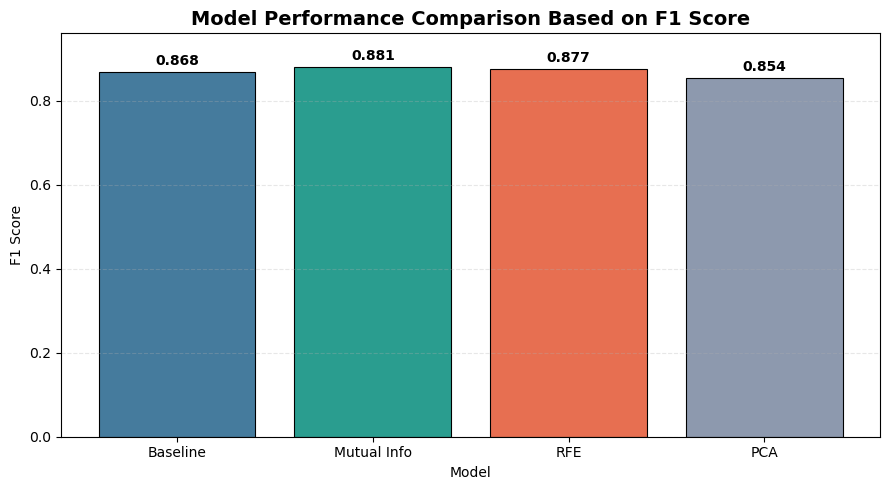

In [111]:
# Graph performance comparison
plot_df = results_df.copy()

# Nama pendek supaya x-axis tak serabut
short_names = {
    "Baseline: All Features": "Baseline",
    "After Mutual Information": "Mutual Info",
    "After RFE": "RFE",
    "After PCA": "PCA"
}

plot_df["Short Model"] = plot_df["Model"].replace(short_names)

plt.figure(figsize=(9, 5))
colors = ["#457B9D", "#2A9D8F", "#E76F51", "#8D99AE"]

bars = plt.bar(
    plot_df["Short Model"],
    plot_df["F1 Score"],
    color=colors,
    edgecolor="black",
    linewidth=0.8
)

plt.title("Model Performance Comparison Based on F1 Score", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("F1 Score")
plt.ylim(0, max(plot_df["F1 Score"]) + 0.08)
plt.grid(axis="y", linestyle="--", alpha=0.3)

# Letak value atas bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.01,
        f"{height:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

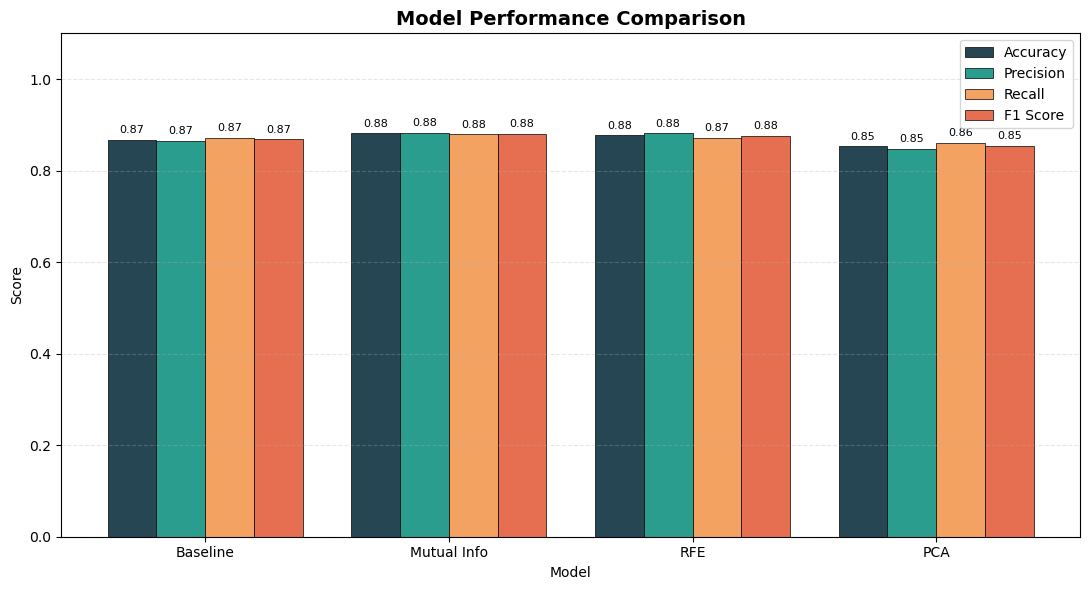

In [112]:
# Graph semua metric
metric_cols = ["Accuracy", "Precision", "Recall", "F1 Score"]

metric_plot = results_df.copy()
metric_plot["Model"] = metric_plot["Model"].replace({
    "Baseline: All Features": "Baseline",
    "After Mutual Information": "Mutual Info",
    "After RFE": "RFE",
    "After PCA": "PCA"
})

x = np.arange(len(metric_plot["Model"]))
width = 0.2

plt.figure(figsize=(11, 6))

colors = ["#264653", "#2A9D8F", "#F4A261", "#E76F51"]

for i, metric in enumerate(metric_cols):
    bars = plt.bar(
        x + (i - 1.5) * width,
        metric_plot[metric],
        width,
        label=metric,
        color=colors[i],
        edgecolor="black",
        linewidth=0.5
    )

    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(x, metric_plot["Model"])
plt.ylim(0, 1.10)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

In [113]:
# Save result untuk rujukan
results_df.to_csv("model_performance_results.csv", index=False)
mi_scores.to_csv("mutual_information_feature_scores.csv", index=False)
rfe_result_df.to_csv("rfe_feature_ranking.csv", index=False)

print("File result disimpan:")
print("- model_performance_results.csv")
print("- mutual_information_feature_scores.csv")
print("- rfe_feature_ranking.csv")

File result disimpan:
- model_performance_results.csv
- mutual_information_feature_scores.csv
- rfe_feature_ranking.csv


# 18. Analisis Ringkas

## Dataset Selection
Dataset utama yang digunakan ialah data ridership pengangkutan awam. Dataset ini sesuai kerana ridership harian boleh dipengaruhi oleh faktor luar seperti cuaca, cuti umum, hujung minggu dan harga minyak.

## Data Integration
Data ridership digabungkan dengan data harga minyak, cuti umum Malaysia dan data cuaca Kuala Lumpur. Semua dataset digabungkan menggunakan column `date`.

## Data Preprocessing
Missing value dikendalikan menggunakan kaedah yang sesuai untuk data masa. Data fuel price yang asalnya mingguan ditukar kepada harian menggunakan forward fill. Feature kategori seperti `day_name` ditukar kepada bentuk nombor menggunakan one-hot encoding. Data numerik pula distandardkan menggunakan StandardScaler.

## Feature Selection
Dua teknik feature selection digunakan iaitu Mutual Information dan Recursive Feature Elimination. Mutual Information digunakan untuk mengukur hubungan feature dengan target, manakala Recursive Feature Elimination memilih feature dengan membuang feature yang kurang penting secara berperingkat.

## Model Performance
Prestasi model dibandingkan sebelum dan selepas feature selection. Perbandingan dibuat menggunakan Accuracy, Precision, Recall dan F1 Score. Jika model selepas feature selection memberi result yang hampir sama atau lebih baik, ini menunjukkan feature yang dipilih sudah cukup mewakili maklumat penting dalam dataset.

## Kesimpulan
Kajian ini menunjukkan bahawa integrasi beberapa sumber data boleh digunakan untuk membina model ramalan permintaan pengangkutan awam. Feature selection juga membantu mengenal pasti feature yang lebih penting dan mengurangkan feature yang kurang memberi kesan kepada model.

# 19. Text Untuk Summary

## Dataset Description

The main dataset used in this project is the public transport ridership dataset. It contains daily ridership records for different public transport services. The dataset was integrated with fuel price data, Malaysia public holiday data, and Kuala Lumpur weather data.

The reason for choosing this dataset is because public transport demand may be affected by external factors such as fuel prices, weather conditions, weekends, and public holidays.

## Problem Context

The objective of this project is to predict whether a particular day has high public transport demand. The target variable is `high_demand`. A day is labelled as high demand if the total ridership is higher than the median value.

## Data Preprocessing

Several preprocessing steps were performed. Missing ridership values were filled with zero. Fuel price data was converted from weekly data into daily data using forward fill. Public holiday data was converted into a binary feature. Weather data was collected using Open-Meteo API. The categorical variable `day_name` was encoded using one-hot encoding. StandardScaler was used to standardize the numerical features.

## Feature Selection

Two feature selection techniques were used in this project. The first method is Mutual Information, which measures the relationship between each feature and the target variable. The second method is Recursive Feature Elimination, which removes less important features step by step until the selected number of features remains.

## Model Evaluation

Logistic Regression was used as the classification model. The model was evaluated before and after feature selection. The evaluation metrics used were Accuracy, Precision, Recall, and F1 Score.

## Conclusion

The project successfully applied data integration, data preprocessing, feature selection, dimensionality reduction, and model evaluation. The result shows how selected features affect the performance of the model in predicting high public transport demand.